# Оптимизация инвестиционного портфеля по Марковицу
## Расчёт эффективных портфелей на основе исторических доходностей акций

---

> Ноутбук реализует классическую **портфельную теорию Марковица**: на основе исторических доходностей
> нескольких акций строится ковариационная матрица, а затем аналитически (без перебора и без
> численной оптимизации) находятся веса двух эффективных портфелей:
>
> 1. **Портфель с заданной целевой доходностью** — минимизирует риск при фиксированном уровне ожидаемой доходности.
> 2. **Портфель минимальной дисперсии** — портфель с наименьшим возможным риском среди всех допустимых портфелей.

**Технологический стек:** Python 3, `yfinance`, `pandas`, `numpy`, `matplotlib`  
**Активы:** JNJ, JPM, PG, KO, XOM — 5 «голубых фишек» разных секторов (здравоохранение, финансы, потребительские товары, напитки, энергетика)  
**Период данных:** 2024-01-01 – 2025-01-01 (дневные котировки, 1 год)


---
## 1. Загрузка данных

Используем библиотеку `yfinance` для загрузки дневных котировок пяти акций за 2024 год.
Помимо цен закрытия (`Close`), нам нужны данные о **дивидендах** (`Dividends`), чтобы корректно
посчитать полную доходность (total return), а не только доходность за счёт изменения цены.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["JNJ", "JPM", "PG", "KO", "XOM"]

raw = yf.download(
    tickers,
    start = "2024-01-01",
    end = "2025-01-01",
    auto_adjust = False,
    actions = True,
    group_by = "ticker")

[*********************100%***********************]  5 of 5 completed

---
## 2. Расчёт доходностей активов

Для каждой акции считаем **дневную полную доходность** по формуле:

$$
r_t = \frac{(P_t - P_{t-1}) + D_t}{P_{t-1}}
$$

где $P_t$ — цена закрытия в день $t$, а $D_t$ — дивиденды, выплаченные в день $t$ (если есть).
Учёт дивидендов важен: без него систематически занижается доходность акций с высокой дивидендной
доходностью (в нашей выборке это в первую очередь JNJ, KO и XOM).

После расчёта строк с пропусками (первый день, для которого нет $P_{t-1}$) — удаляем.

In [2]:
returns_dict = {}

for ticker in tickers:
    price = raw[ticker]["Close"]
    dividends = raw[ticker]["Dividends"]
    r = (price.diff() + dividends) / price.shift(1)
    returns_dict[ticker] = r

returns = pd.DataFrame(returns_dict).dropna()

---
## 3. Ожидаемая доходность и ковариационная матрица

Портфельная теория Марковица оперирует двумя ключевыми объектами:

- **Вектор ожидаемых доходностей** $E = (E_1, \dots, E_n)$ — здесь оценивается как выборочное
  среднее дневных доходностей каждой акции;
- **Ковариационная матрица** $C$ — показывает не только волатильность каждой отдельной акции
  (диагональные элементы — дисперсии), но и то, как активы движутся друг относительно друга
  (недиагональные элементы — ковариации). Именно ковариации между активами дают эффект
  диверсификации: комбинируя слабо или отрицательно коррелированные активы, можно снизить
  общий риск портфеля ниже риска любого отдельного актива.

Также сразу считаем обратную матрицу $C^{-1}$ — она понадобится ниже для аналитического решения
задачи оптимизации.

In [3]:
E = returns.mean().values
C = returns.cov().values
C_inv = np.linalg.inv(C)
n = len(tickers)
one = np.ones(n)

print("\nКовариационная матрица:")
cov_matrix_df = pd.DataFrame(C, index=tickers, columns=tickers)
print(cov_matrix_df)


Ковариационная матрица:
          JNJ       JPM        PG        KO       XOM
JNJ  0.000089  0.000027  0.000026  0.000033  0.000018
JPM  0.000027  0.000219 -0.000011  0.000005  0.000054
PG   0.000026 -0.000011  0.000089  0.000035 -0.000001
KO   0.000033  0.000005  0.000035  0.000064  0.000016
XOM  0.000018  0.000054 -0.000001  0.000016  0.000145

**Как читать матрицу:** на диагонали — дисперсии дневных доходностей каждой акции (у XOM и JPM
волатильность заметно выше, чем у «защитных» JNJ и PG). Недиагональный элемент JPM–PG отрицателен
(-0.000011) — это единственная пара с отрицательной ковариацией в выборке, что даёт наибольший
диверсификационный эффект при их совместном удержании.

---
## 4. Эффективный портфель с заданной целевой доходностью

Классическая задача Марковица — найти веса портфеля $x = (x_1, \dots, x_n)$, которые минимизируют
дисперсию портфеля $x^T C x$ при двух ограничениях:

$$
x^T \mathbf{1} = 1, \qquad x^T E = M
$$

то есть сумма весов равна единице (полное инвестирование, короткие позиции разрешены — веса могут
быть отрицательными), а ожидаемая доходность портфеля равна заданной целевой доходности $M$.

Решение через множители Лагранжа выражается в замкнутом виде через вспомогательные скаляры:

$$
\alpha = E^T C^{-1} E, \quad \beta = \mathbf{1}^T C^{-1} E, \quad \gamma = \mathbf{1}^T C^{-1} \mathbf{1}, \quad \delta = \alpha\gamma - \beta^2
$$

и итоговую формулу оптимальных весов:

$$
x^*(M) = C^{-1}\left[ M \left(\frac{\gamma E - \beta \mathbf{1}}{\delta}\right) + \left(\frac{\alpha \mathbf{1} - \beta E}{\delta}\right) \right]
$$

В коде ниже эта формула реализована через промежуточные векторы `v1` и `v2`. В качестве целевой
доходности взято $M = 0{,}001$ (0,1% в день).

In [4]:
alpha = E @ C_inv @ E
betta = one @ C_inv @ E
gamma = one @ C_inv @ one
delta = alpha * gamma - betta * betta

M = 0.001

v1 = - (gamma / delta) * E + (betta / delta) * one
v2 = (betta / delta) * E - (alpha / delta) * one
x_opt_m = - M * (C_inv @ v1) - (C_inv @ v2)

print(f"\nДоли ценных бумаг в эффективном портфеле с ожидаемой доходностью портфеля M = {M}")
for ticker, w in zip(tickers, x_opt_m):
    print(f"{ticker}: {w:.6f}")

print(f"Сумма весов = {x_opt_m.sum():.6f}")
print(f"Ожидаемая доходность = {x_opt_m @ E:.6f}")
print(f"Дисперсия = {x_opt_m.T @ C @ x_opt_m:.6f}")
print(f"Стандартное отклонение = {np.sqrt(x_opt_m.T @ C @ x_opt_m):.6f}")


Доли ценных бумаг в эффективном портфеле с ожидаемой доходностью портфеля M = 0.001
JNJ: -0.219071
JPM: 0.343986
PG: 0.463098
KO: 0.301641
XOM: 0.110345
Сумма весов = 1.000000
Ожидаемая доходность = 0.001000
Дисперсия = 0.000055
Стандартное отклонение = 0.007383

**Интерпретация:** чтобы выйти на целевую дневную доходность 0,1% (≈25,2% годовых при простом
пересчёте), модель предлагает **короткую позицию по JNJ** (-21,9%) и профинансировать за счёт неё
более длинные позиции в PG и JPM — двух активах с наилучшим соотношением доходности и вклада в риск
портфеля. Отрицательный вес — не ошибка, а корректный результат неограниченной (long-short)
оптимизации Марковица; на практике такую позицию нужно проверять на реализуемость (доступность
акции для шорта, комиссии за заём бумаг).

---
## 5. Портфель минимальной дисперсии

Отдельный частный случай задачи — найти портфель с **наименьшим возможным риском** без ограничения
на доходность (ограничение только $x^T\mathbf{1}=1$). Решение также выражается в замкнутом виде:

$$
x^*_{min} = \frac{C^{-1}\mathbf{1}}{\mathbf{1}^T C^{-1} \mathbf{1}}
$$

Этот портфель — самая левая точка на границе эффективности (efficient frontier): любой другой
портфель на границе имеет либо такой же, либо больший риск.

In [5]:
x_opt_min = (C_inv @ one) / (one @ C_inv @ one)

print(f"\nДоли ценных бумаг в эффективном портфеле")
for ticker, w in zip(tickers, x_opt_min):
    print(f"{ticker}: {w:.6f}")

print(f"Сумма весов = {x_opt_min.sum():.6f}")
print(f"Ожидаемая доходность = {x_opt_min @ E:.6f}")
print(f"Дисперсия = {x_opt_min.T @ C @ x_opt_min:.6f}")
print(f"Стандартное отклонение = {np.sqrt(x_opt_min.T @ C @ x_opt_min):.6f}")


Доли ценных бумаг в эффективном портфеле
JNJ: 0.155955
JPM: 0.115613
PG: 0.267932
KO: 0.298465
XOM: 0.162035
Сумма весов = 1.000000
Ожидаемая доходность = 0.000464
Дисперсия = 0.000037
Стандартное отклонение = 0.006071

**Интерпретация:** в отличие от целевого портфеля, здесь все веса положительны — только длинные
позиции. Стандартное отклонение дневной доходности ниже (0,61% против 0,74% у целевого портфеля),
но и ожидаемая доходность заметно скромнее (0,046% в день, ≈11,7% годовых при простом пересчёте).
Это ожидаемо: минимизация риска без ограничений на доходность не может дать более высокую
доходность, чем портфель, специально настроенный под целевую доходность $M$.

---
## 6. Визуализация структуры портфелей

Сравним состав двух портфелей на графике: слева — портфель с целевой доходностью $M=0{,}001$
(видна короткая позиция по JNJ), справа — портфель минимальной дисперсии (все веса положительны).

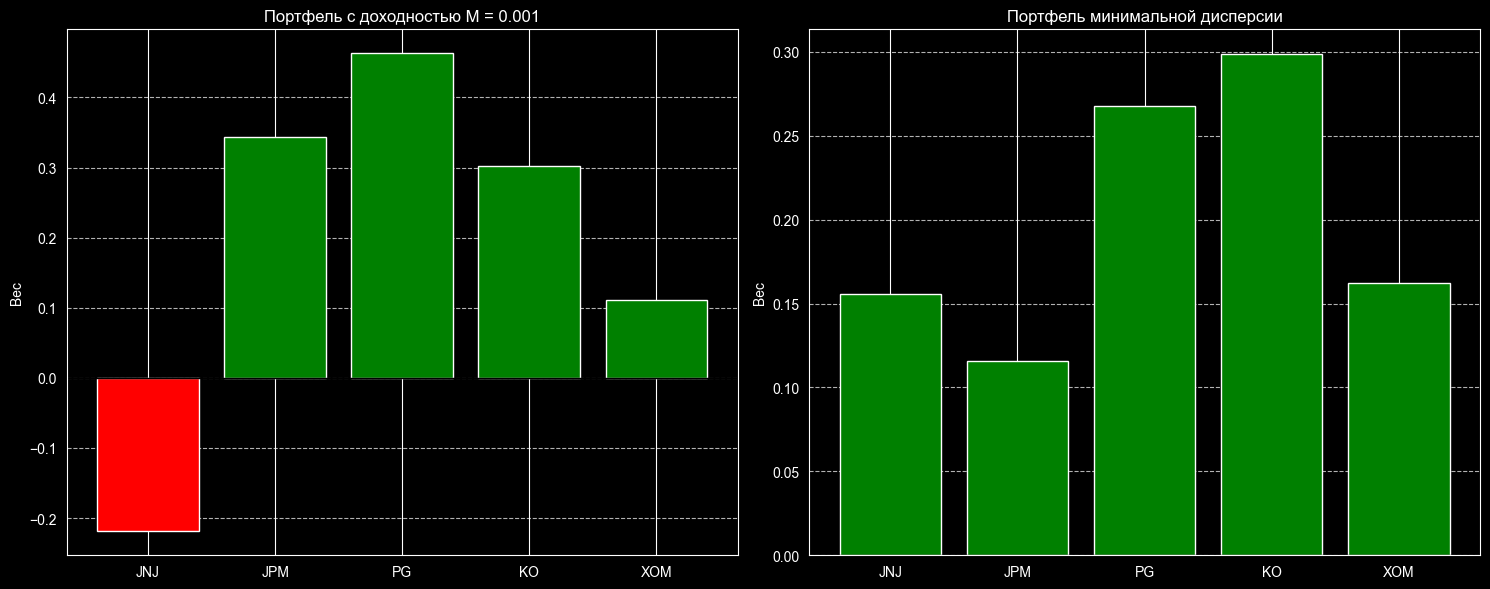

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors_m = ["green" if w > 0 else "red" for w in x_opt_m]
ax1.bar(tickers, x_opt_m, color=colors_m)
ax1.axhline(0, color="black", linewidth=1)
ax1.set_title(f"Портфель с доходностью M = {M}")
ax1.set_ylabel("Вес")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

colors_min = ["green" if w > 0 else "red" for w in x_opt_min]
ax2.bar(tickers, x_opt_min, color=colors_min)
ax2.axhline(0, color="black", linewidth=1)
ax2.set_title("Портфель минимальной дисперсии")
ax2.set_ylabel("Вес")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

---
## 7. Итоги и ограничения

**Что построено:** аналитический (без численных солверов) расчёт двух классических эффективных
портфелей по Марковицу на реальных исторических данных пяти акций за 2024 год — портфеля с заданной
целевой доходностью и портфеля минимальной дисперсии.

| Портфель | Доходность (дневная / годовая~) | Риск (σ, дневной) |
|---|---|---|
| Целевой (M = 0,001) | 0,100% / ≈25,2% | 0,738% |
| Минимальной дисперсии | 0,046% / ≈11,7% | 0,607% |

*Годовая доходность получена простым умножением дневной на 252 торговых дня — грубая оценка без
учёта сложного процента и стационарности параметров во времени.*

**Ограничения модели:**
- Короткие продажи разрешены неявно — для JNJ в целевом портфеле это может быть невыполнимо или
  дорого на практике;
- Ожидаемая доходность и ковариации оценены на единственном годовом окне (2024) — параметры модели
  Марковица известны своей нестабильностью во времени (out-of-sample эта оценка может быть неверна);
- Не учтены транзакционные издержки, налоги и безрисковый актив (то есть это не полная модель CAPM/
  линии рынка капитала, а «чистая» задача Марковица на рискованных активах).

**Возможные развития:** добавить безрисковый актив и построить касательный портфель (tangency
portfolio) / линию рынка капитала, расширить выборку активов, оценивать ковариации на скользящем
окне или с помощью моделей семейства GARCH.